<a href="https://colab.research.google.com/github/steffiprog/ML/blob/main/3_log_reg_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание: линейные модели для NLP**

## **Что будем делать?**
Мы будем предсказывать, к какой категории относится новость: про хоккей или про космос.

## **Часть 1. Практическая работа (8 баллов)**

### **1. Загрузка данных**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups

# Загружаем данные о новостях
categories = ['rec.sport.hockey', 'sci.space']
newsgroups = fetch_20newsgroups(subset='all',
                               categories=categories,
                               shuffle=True,
                               random_state=42)

# Создаём таблицу с данными
data = pd.DataFrame({
    'text': newsgroups.data,
    'category': newsgroups.target  # 0 = хоккей, 1 = космос
})

print("Размер данных:", data.shape)
print("\nПервые 3 текста:")
for i in range(3):
    print(f"Текст {i+1}: {data['text'][i][:100]}...")

Размер данных: (1986, 2)

Первые 3 текста:
Текст 1: From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I....
Текст 2: From: epritcha@s.psych.uiuc.edu ( Evan Pritchard)
Subject: Re: div. and conf. names
Distribution: na...
Текст 3: From: baalke@kelvin.jpl.nasa.gov (Ron Baalke)
Subject: Galileo Update - 04/29/93
Keywords: Galileo, ...


**Задание 1:**
- Сколько всего текстов в датасете?
- Выведите количество текстов в каждой категории

In [ ]:
print("Всего текстов:", len(data))
print("Количество текстов в каждой категории:")
print("Хоккей:", sum(data['category'] == 0))
print("Космос:", sum(data['category'] == 1))


Всего текстов: 1986
Количество текстов в каждой категории:
Хоккей: 999
Космос: 987


### **2. Анализ данных**

In [ ]:
counts = data['category'].value_counts()
if counts[0] > counts[1]:
    print("Категория Хоккей содержит больше текстов")
elif counts[1] > counts[0]:
    print("Категория Космос содержит больше текстов")
else:
    print("Количество текстов в обеих категориях одинаковое")

Категория Хоккей содержит больше текстов


**Вопрос:** Какая категория больше: хоккей или космос?

### **3. Очистка текста**

In [ ]:
import re

def clean_text(text):
    text = text.lower()
    re.sub(r'[^a-zA-Z\s]', '', text)
    re.sub(r'\s+', ' ', text).strip()
    return text

# Применяем функцию
data['clean_text'] = data['text'].apply(clean_text)

# Проверяем
print("До очистки:", data['text'][0][:100])
print("После очистки:", data['clean_text'][0][:100])

До очистки: From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I.
После очистки: from: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
subject: re: vandalizing the sky.
article-i.


### **4. Создание признаков (векторизация)**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(data['clean_text'])
print("Уникальных слов", len(vectorizer.get_feature_names_out()))

Уникальных слов 29204


**Вопрос:** Сколько уникальных слов нашёл CountVectorizer?

### **5. Разделение данных**

In [ ]:
from sklearn.model_selection import train_test_split

# Цель: предсказать категорию (0 или 1)
X = X # что сюда подставить? (признаки)
y = data['category'] # что сюда подставить? (целевая переменная)

# Делим данные на 80% обучение, 20% тест
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Посмотрим на результат (обучающую и тестовую выборки)
print("Размерность обучающей выборки", X_train.shape)
print("Размерность тестовой выборки", X_test.shape)
print("Размерность обучающей выборки (целевая)", y_train.shape)
print("Размерность тестовой выборки (целевая)", y_test.shape)

Размерность обучающей выборки (1588, 29204)
Размерность тестовой выборки (398, 29204)
Размерность обучающей выборки (целевая) (1588,)
Размерность тестовой выборки (целевая) (398,)


### **6. Обучение модели**

In [ ]:
from sklearn.linear_model import LogisticRegression

# Модель логистической регрессии
model = LogisticRegression(max_iter=1000, random_state=42)
# Обучение
model.fit(X_train, y_train)
# Предсказания для тестовых данных
y_p = model.predict(X_test)
print("Предсказание первых 30 категорий:", y_p[:30])

Предсказание первых 30 категорий: [0 0 1 1 0 0 0 0 0 1 1 0 1 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0 1 1]


### **7. Оценка модели**

In [ ]:
from sklearn.metrics import accuracy_score

# Accuracy (точность) модели
accuracy = accuracy_score(y_test, y_p)
print(f"Точность модели: {accuracy * 100:.2f}%")
# Точность (нереалистично) высокая, возможно, из-за утечки данных из тестового датасета в обучающий. Либо модель действительно очень хорошо распознает темы, так как категорий только 2 и они не близки по теме-расстоянию.



Точность модели: 99.50%


**Вопрос:** Какая точность у вашей модели? Что это значит?

### **8. Анализ ошибок**

Confusion matrix:
[[201   1]
 [  1 195]]


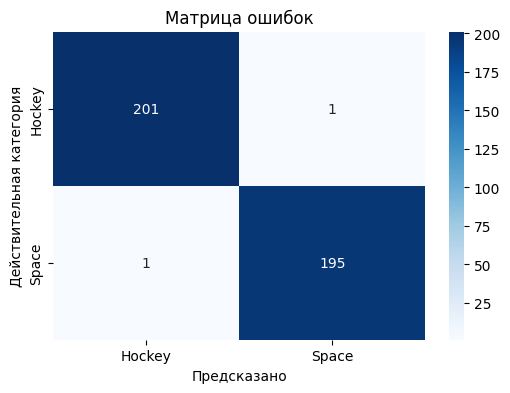

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# матрица ошибок
cm = confusion_matrix(y_test, y_p)

print("Confusion matrix:")
print(cm)

# визуализация
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Hockey', 'Space'],
            yticklabels=['Hockey', 'Space'])
plt.xlabel('Предсказано')
plt.ylabel('Действительная категория')
plt.title('Матрица ошибок')
plt.show()

**Вопрос:** Сколько текстов про космос модель приняла за хоккей?

**Ответ:** 1 текст. Также 1 текст про хоккей, наоборот, принят за космос.